In [1]:
print("Работает")

Работает


In [1]:
import pandas as pd

xl = pd.ExcelFile('../data/raw/умное_потребление_данные.xlsx')
print(xl.sheet_names)

['README', 'Romir_ИПУ', 'Romir_Кошелек', 'Демография_Сегменты', 'Домохозяйства_Профили', 'NoBuy_Опрос', 'СберИндекс_Динамика', 'СберИндекс_Категории', 'СберИндекс_Офлайн', 'СберПро_Тренды2025', 'Теория_Формула', 'Флаги', 'STM_Опыт_Покупок', 'STM_Топ_Категорий', 'STM_Мотивация', 'Rosstat_Оборот_Розницы']


In [6]:
import sqlite3
import pandas as pd

# 1. Загружаем Excel заново
xl = pd.ExcelFile('../data/raw/умное_потребление_данные.xlsx')
print("Всего листов:", len(xl.sheet_names))

# 2. Словарь: лист Excel → таблица в SQLite
sheets = {
    # --- старые 15 ---
    'Romir_ИПУ':              'consumer_confidence',
    'Romir_Кошелек':          'wallet_metrics',
    'Демография_Сегменты':    'demographics',
    'Домохозяйства_Профили':  'household_profiles',
    'NoBuy_Опрос':            'nobuy_survey',
    'СберИндекс_Динамика':    'sberindex_dynamics',
    'СберИндекс_Категории':   'sberindex_categories',
    'СберИндекс_Офлайн':      'sberindex_offline',
    'СберПро_Тренды2025':     'sberpro_trends',
    'Теория_Формула':         'theory_formulas',
    'Флаги':                  'data_flags',
    'STM_Опыт_Покупок':       'stm_experience',
    'STM_Топ_Категорий':      'stm_categories',
    'STM_Мотивация':          'stm_motivation',
    'Rosstat_Оборот_Розницы': 'retail_turnover',
    # --- новые 8 ---
    'HSE_Сбережения_Кредиты':    'hse_savings_credits',
    'HSE_Защита_Прав':           'hse_consumer_rights',
    'HSE_Портрет_Потребителя':   'hse_consumer_portrait',
    'HSE_Макро_Контекст':        'hse_macro_context',
    'Chizhik_ВШЭ_Индекс':        'chizhik_index',
    'Chizhik_ВШЭ_Сегменты':      'chizhik_segments',
    'Chizhik_ВШЭ_Паттерны':      'chizhik_patterns',
    'Rosstat_Структура_Расходов':'rosstat_spending',
    'Rosstat_Интернет_Торговля': 'rosstat_online',
}

# 3. Загрузка в SQLite
conn = sqlite3.connect('../data/smart_consumption.db')

for sheet, table in sheets.items():
    if sheet not in xl.sheet_names:
        print(f"⚠ Пропущен (нет листа): {sheet}")
        continue
    df = pd.read_excel(xl, sheet_name=sheet)
    df = df.dropna(axis=1, how='all')
    df = df.dropna(axis=0, how='all')
    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
    df.to_sql(table, conn, if_exists='replace', index=False)
    print(f"{sheet:35s} → {table:30s} | {len(df)} строк")

conn.close()
print("\n✅ База обновлена: data/smart_consumption.db")

Всего листов: 25
Romir_ИПУ                           → consumer_confidence            | 14 строк
Romir_Кошелек                       → wallet_metrics                 | 8 строк
Демография_Сегменты                 → demographics                   | 3 строк
Домохозяйства_Профили               → household_profiles             | 5 строк
NoBuy_Опрос                         → nobuy_survey                   | 50 строк
СберИндекс_Динамика                 → sberindex_dynamics             | 7 строк
СберИндекс_Категории                → sberindex_categories           | 18 строк
СберИндекс_Офлайн                   → sberindex_offline              | 28 строк
СберПро_Тренды2025                  → sberpro_trends                 | 3 строк
Теория_Формула                      → theory_formulas                | 7 строк
Флаги                               → data_flags                     | 3 строк
STM_Опыт_Покупок                    → stm_experience                 | 6 строк
STM_Топ_Категорий              

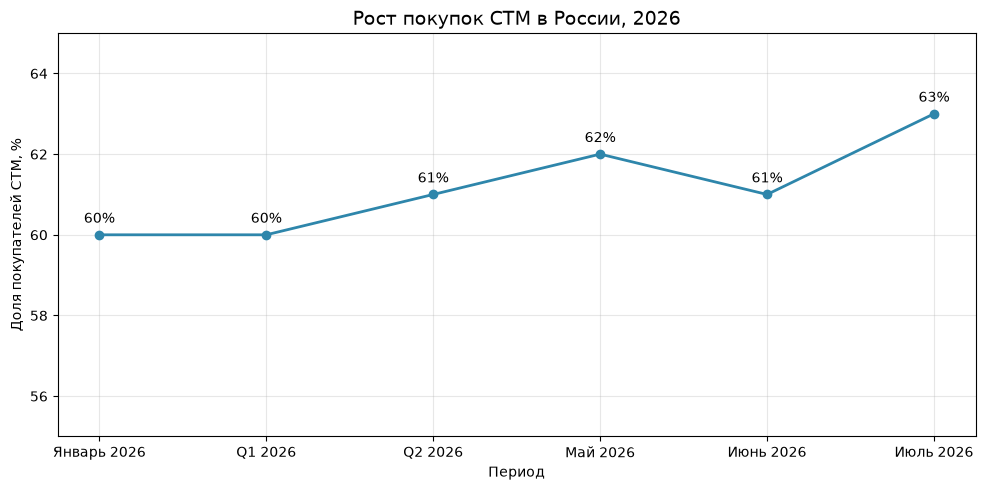

In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')

query = """
SELECT period, regular_or_sometimes_total_pct
FROM stm_experience
ORDER BY 
    CASE period
        WHEN 'Январь 2026' THEN 1
        WHEN 'Q1 2026'     THEN 2
        WHEN 'Q2 2026'     THEN 3
        WHEN 'Май 2026'    THEN 4
        WHEN 'Июнь 2026'   THEN 5
        WHEN 'Июль 2026'   THEN 6
    END
"""

df = pd.read_sql(query, conn)
conn.close()

plt.figure(figsize=(10, 5))
plt.plot(df['period'], df['regular_or_sometimes_total_pct'], 
         marker='o', linewidth=2, color='#2E86AB')
plt.title('Рост покупок СТМ в России, 2026', fontsize=14)
plt.xlabel('Период')
plt.ylabel('Доля покупателей СТМ, %')
plt.ylim(55, 65)
plt.grid(alpha=0.3)

for i, v in enumerate(df['regular_or_sometimes_total_pct']):
    plt.text(i, v + 0.3, f'{v}%', ha='center')

plt.tight_layout()
plt.savefig('../visualizations/stm_dynamics.png', dpi=150)
plt.show()

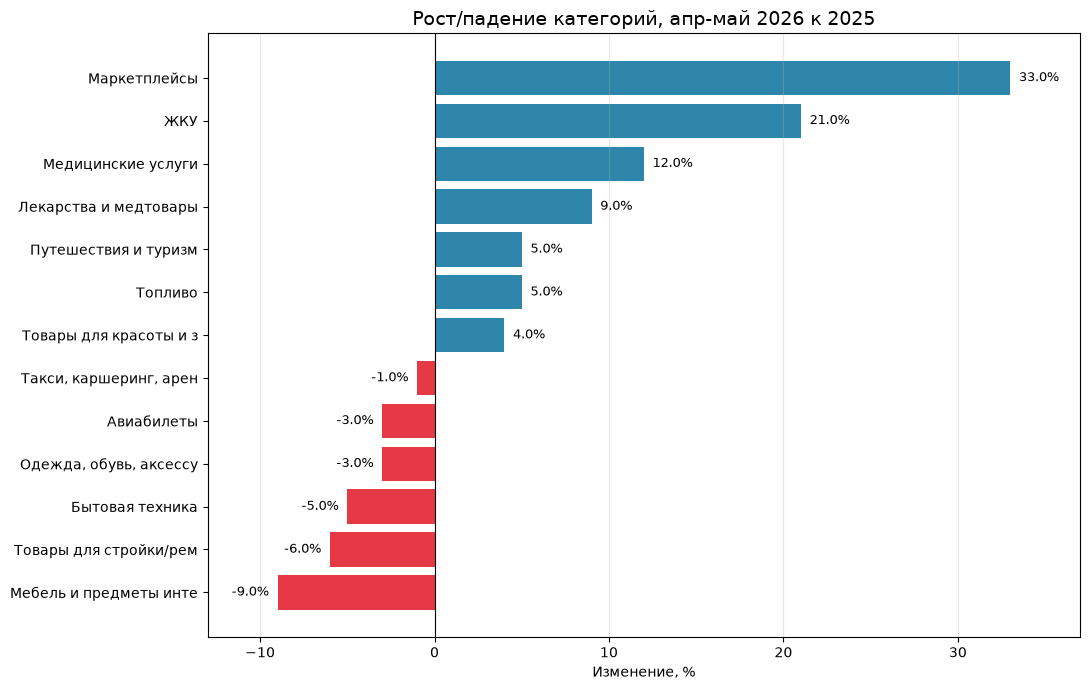

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT category, growth_pct_apr_may_2026 FROM sberindex_categories", conn)
conn.close()

# Числа
df['growth_pct_apr_may_2026'] = pd.to_numeric(df['growth_pct_apr_may_2026'], errors='coerce')

# Фильтр подкатегорий
df = df[df['category'].str.contains('из них', na=False, regex=False)].copy()

# Чистим название и обрезаем до 22 символов
df['category'] = (df['category']
                  .str.replace('из них:', '', regex=False)
                  .str.strip()
                  .str[:22])

# Сортировка
df = df.sort_values('growth_pct_apr_may_2026')

# Цвета
colors = ['#E63946' if x < 0 else '#2E86AB' for x in df['growth_pct_apr_may_2026']]

# График с широким левым полем
fig, ax = plt.subplots(figsize=(11, 7))
fig.subplots_adjust(left=0.28)

ax.barh(df['category'], df['growth_pct_apr_may_2026'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Рост/падение категорий, апр-май 2026 к 2025', fontsize=14)
ax.set_xlabel('Изменение, %')
ax.grid(alpha=0.3, axis='x')

# Подписи: справа для плюсов, слева для минусов
for i, v in enumerate(df['growth_pct_apr_may_2026']):
    if v > 0:
        ax.text(v + 0.5, i, f'{v}%', va='center', ha='left', fontsize=9)
    else:
        ax.text(v - 0.5, i, f'{v}%', va='center', ha='right', fontsize=9)

# Запас по краям, чтобы подписи не вылезали
ax.set_xlim(df['growth_pct_apr_may_2026'].min() - 4,
            df['growth_pct_apr_may_2026'].max() + 4)

plt.tight_layout()
plt.savefig('../visualizations/categories_change.png', dpi=150)
plt.show()

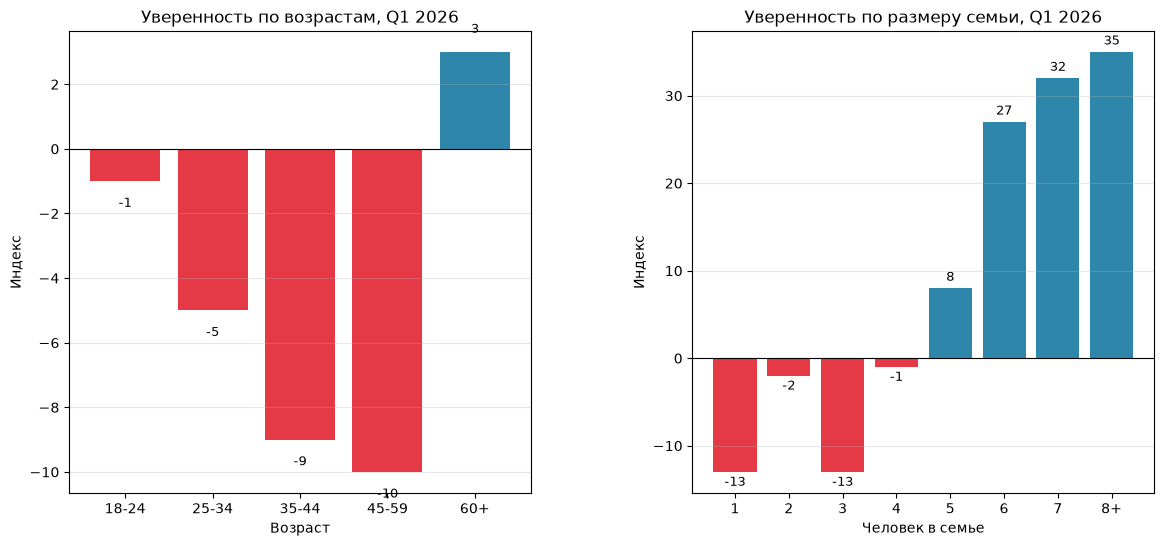

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT dimension_type, dimension_value, index_value FROM consumer_confidence", conn)
conn.close()

age = df[df['dimension_type'] == 'age_group'].copy()
age['index_value'] = pd.to_numeric(age['index_value'], errors='coerce')

hh = df[df['dimension_type'] == 'household_size'].copy()
hh['index_value'] = pd.to_numeric(hh['index_value'], errors='coerce')

def get_colors(values):
    return ['#E63946' if x < 0 else '#2E86AB' for x in values]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.35)

# --- Возраст ---
ax1 = axes[0]
ax1.bar(age['dimension_value'], age['index_value'], color=get_colors(age['index_value']))
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Уверенность по возрастам, Q1 2026')
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Индекс')
ax1.grid(alpha=0.3, axis='y')
for i, v in enumerate(age['index_value']):
    ax1.text(i, v + (0.5 if v >= 0 else -0.5), f'{v}', ha='center',
             va='bottom' if v >= 0 else 'top', fontsize=9)

# --- Размер семьи ---
ax2 = axes[1]
ax2.bar(hh['dimension_value'], hh['index_value'], color=get_colors(hh['index_value']))
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Уверенность по размеру семьи, Q1 2026')
ax2.set_xlabel('Человек в семье')
ax2.set_ylabel('Индекс')
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(hh['index_value']):
    ax2.text(i, v + (0.5 if v >= 0 else -0.5), f'{v}', ha='center',
             va='bottom' if v >= 0 else 'top', fontsize=9)

plt.savefig('../visualizations/consumer_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

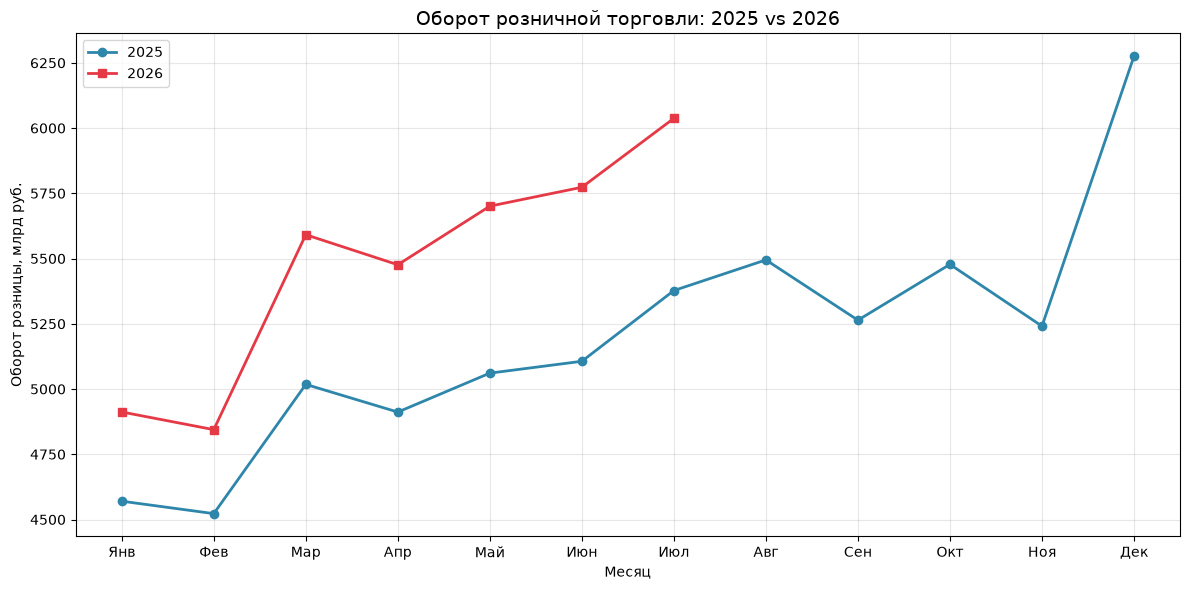


Рост 2026 к 2025 по месяцам:
  Янв: +7.5%
  Фев: +7.1%
  Мар: +11.4%
  Апр: +11.5%
  Май: +12.6%
  Июн: +13.1%
  Июл: +12.3%


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect('../data/smart_consumption.db')

# Берём только категорию "Всего"
df = pd.read_sql("""
    SELECT year, month, value_million_rub
    FROM retail_turnover
    WHERE category = 'Всего'
""", conn)
conn.close()

# Порядок месяцев
month_order = ['январь','февраль','март','апрель','май','июнь',
               'июль','август','сентябрь','октябрь','ноябрь','декабрь']

df['month_num'] = df['month'].apply(lambda x: month_order.index(x) + 1 if x in month_order else None)
df['value_mlrd'] = df['value_million_rub'] / 1000  # в млрд рублей

df25 = df[df['year'] == 2025].sort_values('month_num')
df26 = df[df['year'] == 2026].sort_values('month_num')

fig, ax = plt.subplots(figsize=(12, 6))

# Линия 2025
ax.plot(df25['month_num'], df25['value_mlrd'], marker='o', linewidth=2,
        color='#2E86AB', label='2025')

# Линия 2026
ax.plot(df26['month_num'], df26['value_mlrd'], marker='s', linewidth=2,
        color='#E63946', label='2026')

# Подписи месяцев
ax.set_xticks(range(1, 13))
ax.set_xticklabels([m[:3].capitalize() for m in month_order])
ax.set_xlabel('Месяц')
ax.set_ylabel('Оборот розницы, млрд руб.')
ax.set_title('Оборот розничной торговли: 2025 vs 2026', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0.5, 12.5)

plt.tight_layout()
plt.savefig('../visualizations/retail_turnover.png', dpi=150)
plt.show()

# Считаем рост по месяцам, где есть оба года
print("\nРост 2026 к 2025 по месяцам:")
merged = df25.merge(df26, on='month_num', suffixes=('_2025', '_2026'))
merged['yoy'] = (merged['value_mlrd_2026'] - merged['value_mlrd_2025']) * 100 / merged['value_mlrd_2025']
for _, r in merged.iterrows():
    print(f"  {r['month_2025'][:3].capitalize()}: {r['yoy']:+.1f}%")

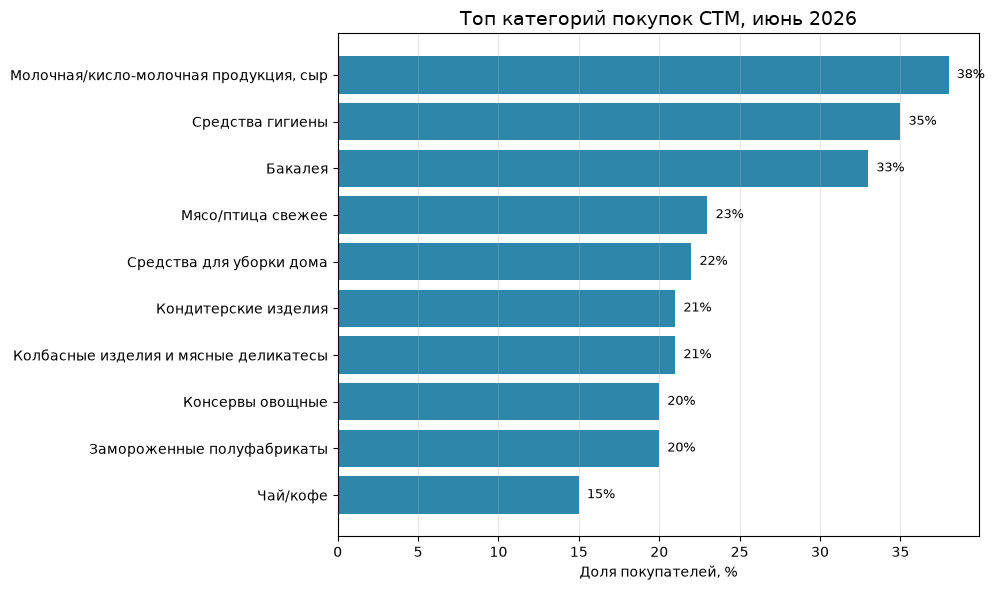

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT category, share_pct_june_2026 FROM stm_categories", conn)
conn.close()

# Убираем NULL и сортируем
df = df.dropna(subset=['share_pct_june_2026'])
df = df.sort_values('share_pct_june_2026')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df['category'], df['share_pct_june_2026'], color='#2E86AB')

ax.set_title('Топ категорий покупок СТМ, июнь 2026', fontsize=14)
ax.set_xlabel('Доля покупателей, %')
ax.grid(alpha=0.3, axis='x')

for bar, v in zip(bars, df['share_pct_june_2026']):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v}%',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visualizations/stm_categories.png', dpi=150)
plt.show()

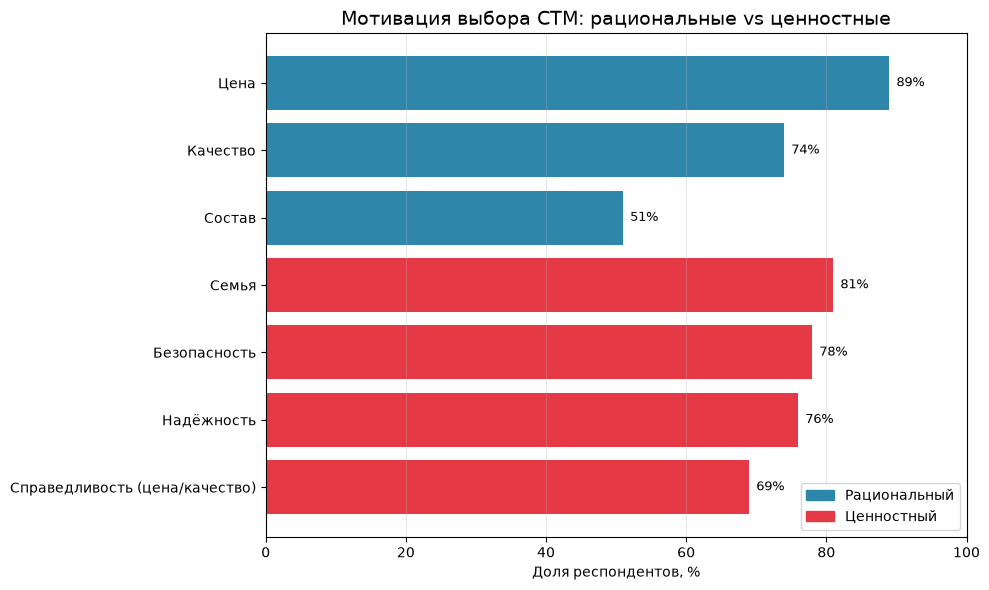

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT factor_type, factor, share_pct FROM stm_motivation", conn)
conn.close()

# Сортируем внутри каждой группы
df = df.sort_values(['factor_type', 'share_pct'], ascending=[False, True])

colors = {'Рациональный': '#2E86AB', 'Ценностный': '#E63946'}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df['factor'], df['share_pct'],
               color=[colors.get(t, '#999') for t in df['factor_type']])

ax.set_title('Мотивация выбора СТМ: рациональные vs ценностные', fontsize=14)
ax.set_xlabel('Доля респондентов, %')
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(0, 100)

for bar, v in zip(bars, df['share_pct']):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v}%',
            va='center', fontsize=9)

# Легенда
from matplotlib.patches import Patch
legend = [Patch(color='#2E86AB', label='Рациональный'),
          Patch(color='#E63946', label='Ценностный')]
ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('../visualizations/stm_motivation.png', dpi=150)
plt.show()

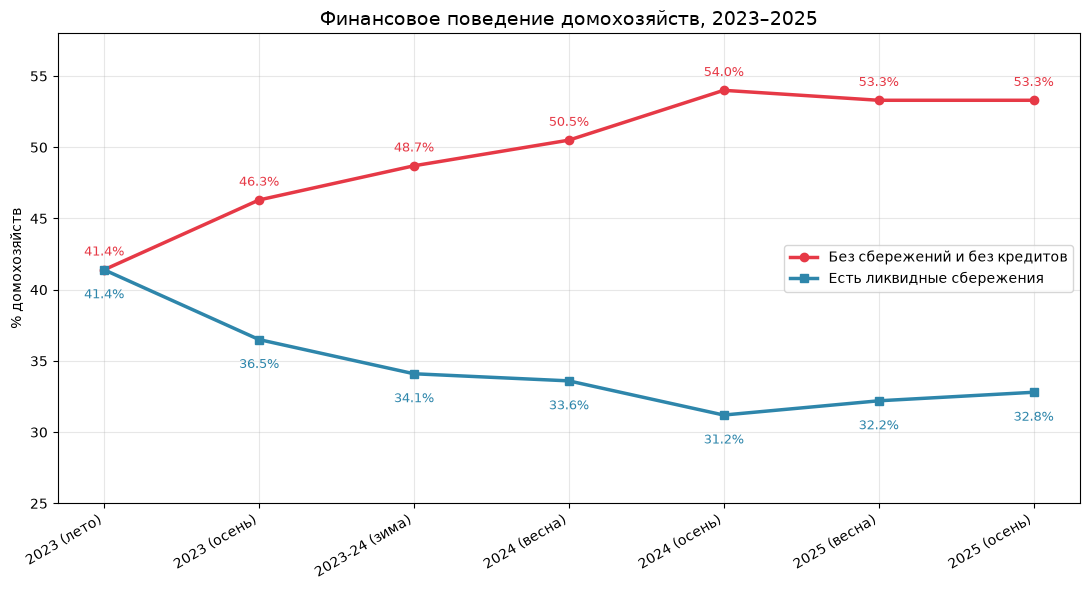

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT * FROM hse_savings_credits", conn)
conn.close()

# Убираем строку с источником, если попала
df = df[df['wave'].str.contains('20', na=False)].copy()

# Числа
for col in ['нет_сбережений_нет_кредитов_pct', 'есть_ликвидные_сбережения_pct']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Короткие подписи
df['label'] = ['2023 (лето)', '2023 (осень)', '2023-24 (зима)',
               '2024 (весна)', '2024 (осень)', '2025 (весна)', '2025 (осень)']

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df['label'], df['нет_сбережений_нет_кредитов_pct'],
        marker='o', linewidth=2.5, color='#E63946',
        label='Без сбережений и без кредитов')
ax.plot(df['label'], df['есть_ликвидные_сбережения_pct'],
        marker='s', linewidth=2.5, color='#2E86AB',
        label='Есть ликвидные сбережения')

ax.set_title('Финансовое поведение домохозяйств, 2023–2025', fontsize=14)
ax.set_ylabel('% домохозяйств')
ax.grid(alpha=0.3)
ax.legend(loc='center right')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(df['нет_сбережений_нет_кредитов_pct']):
    ax.text(i, v + 1, f'{v}%', ha='center', fontsize=9, color='#E63946')
for i, v in enumerate(df['есть_ликвидные_сбережения_pct']):
    ax.text(i, v - 2, f'{v}%', ha='center', fontsize=9, color='#2E86AB')

ax.set_ylim(25, 58)
plt.tight_layout()
plt.savefig('../visualizations/hse_savings.png', dpi=150)
plt.show()

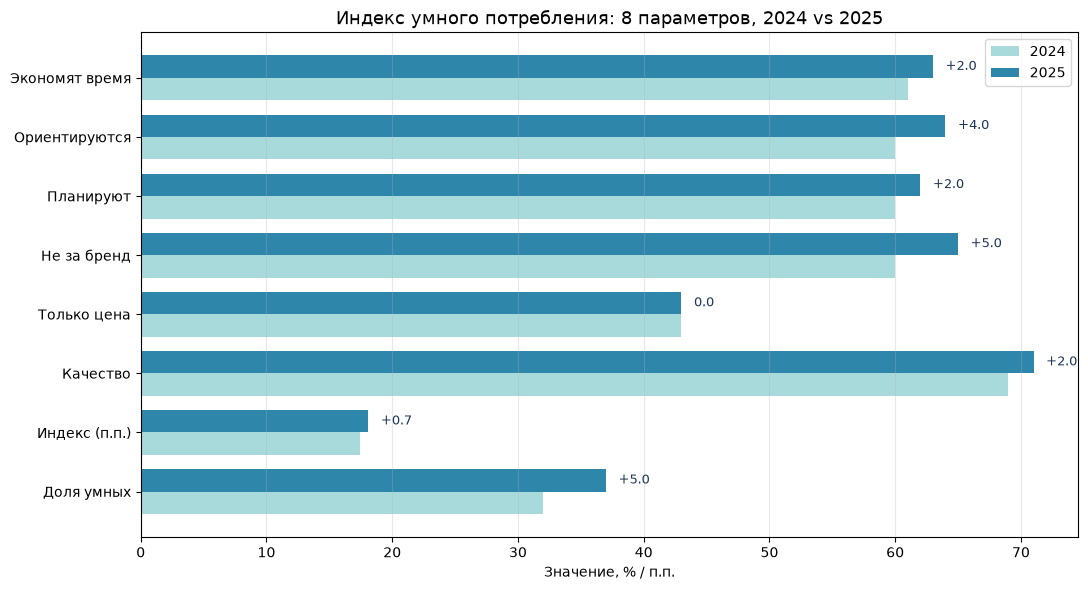

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT * FROM chizhik_index", conn)
conn.close()

# Убираем строку-источник, если попала
df = df.dropna(subset=['value_2024', 'value_2025']).copy()
df['value_2024'] = pd.to_numeric(df['value_2024'], errors='coerce')
df['value_2025'] = pd.to_numeric(df['value_2025'], errors='coerce')

# Считаем изменение
df['delta'] = df['value_2025'] - df['value_2024']

# Короткие подписи
short = {
    'Доля умных потребителей (совокупный индекс)': 'Доля умных',
    'Индекс умного потребления (п.п.)': 'Индекс (п.п.)',
    'Ориентируются на приемлемое качество': 'Качество',
    'Ориентируются исключительно на низкую цену': 'Только цена',
    'Не готовы переплачивать за известный бренд': 'Не за бренд',
    'Планируют покупки заранее': 'Планируют',
    'Легко ориентируются среди множества предложений': 'Ориентируются',
    'Стремятся минимизировать время на покупки': 'Экономят время',
}
df['short'] = df['metric'].map(short).fillna(df['metric'].str[:20])

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(df))
width = 0.38

ax.barh(x - width/2, df['value_2024'], width, label='2024', color='#A8DADC')
ax.barh(x + width/2, df['value_2025'], width, label='2025', color='#2E86AB')

ax.set_yticks(x)
ax.set_yticklabels(df['short'])
ax.set_xlabel('Значение, % / п.п.')
ax.set_title('Индекс умного потребления: 8 параметров, 2024 vs 2025', fontsize=13)
ax.legend()
ax.grid(alpha=0.3, axis='x')

for i, d in enumerate(df['delta']):
    ax.text(df['value_2025'].iloc[i] + 1, i + width/2,
            f'+{d:.1f}' if d > 0 else f'{d:.1f}',
            va='center', fontsize=9, color='#1D3557')

plt.tight_layout()
plt.savefig('../visualizations/chizhik_index.png', dpi=150)
plt.show()

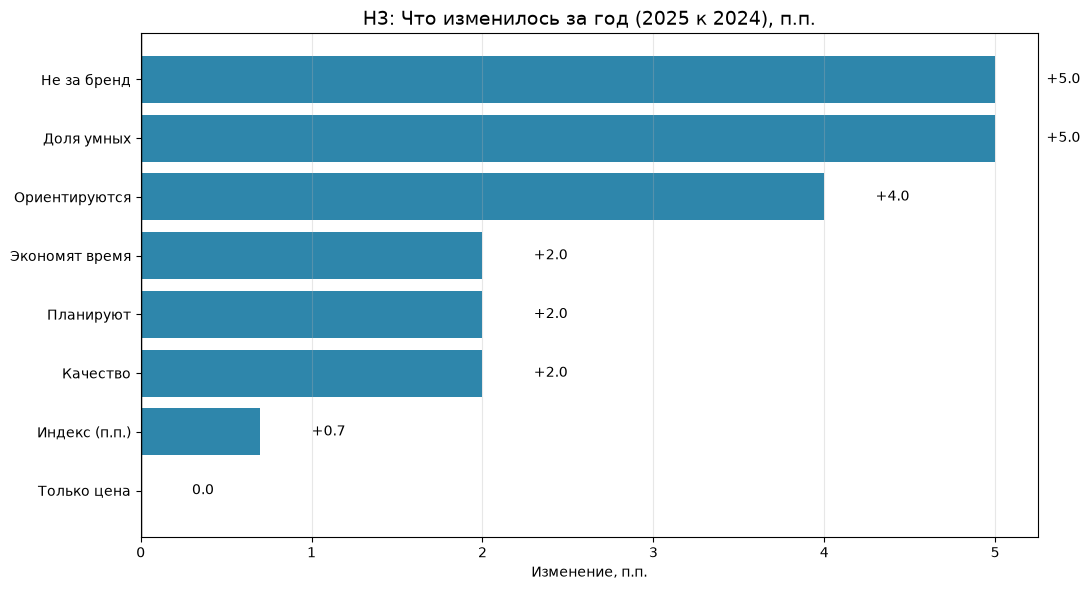


=== ВЫВОД H3 ===
«Только цена» изменилось на: +0.0 п.п. (не изменилось)
«Доля умных» выросла на: +5.0 п.п.
«Качество» выросло на: +2.0 п.п.
«Не за бренд» выросло на: +5.0 п.п.

✅ H3 ПОДТВЕРЖДАЕТСЯ: умное потребление ≠ экономия


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect('../data/smart_consumption.db')
df = pd.read_sql("SELECT * FROM chizhik_index", conn)
conn.close()

# Убираем строку-источник
df = df.dropna(subset=['value_2024', 'value_2025']).copy()
df['value_2024'] = pd.to_numeric(df['value_2024'], errors='coerce')
df['value_2025'] = pd.to_numeric(df['value_2025'], errors='coerce')

# Считаем изменение в п.п.
df['delta'] = df['value_2025'] - df['value_2024']

# Короткие подписи
short = {
    'Доля умных потребителей (совокупный индекс)': 'Доля умных',
    'Индекс умного потребления (п.п.)': 'Индекс (п.п.)',
    'Ориентируются на приемлемое качество': 'Качество',
    'Ориентируются исключительно на низкую цену': 'Только цена',
    'Не готовы переплачивать за известный бренд': 'Не за бренд',
    'Планируют покупки заранее': 'Планируют',
    'Легко ориентируются среди множества предложений': 'Ориентируются',
    'Стремятся минимизировать время на покупки': 'Экономят время',
}
df['short'] = df['metric'].map(short).fillna(df['metric'].str[:20])

# Сортируем по изменению
df = df.sort_values('delta')

# Цвета: серый для нуля, зелёный для роста, красный для падения
def get_color(d):
    if d > 0.5: return '#2E86AB'   # рост — синий
    if d < -0.5: return '#E63946'  # падение — красный
    return '#999999'               # ноль — серый

colors = [get_color(d) for d in df['delta']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df['short'], df['delta'], color=colors)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('H3: Что изменилось за год (2025 к 2024), п.п.', fontsize=14)
ax.set_xlabel('Изменение, п.п.')
ax.grid(alpha=0.3, axis='x')

for bar, v in zip(bars, df['delta']):
    x = v + 0.3 if v >= 0 else v - 0.3
    ha = 'left' if v >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f'+{v:.1f}' if v > 0 else f'{v:.1f}',
            va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.savefig('../visualizations/H3_smart_not_saving.png', dpi=150)
plt.show()

# Текстовый вывод для статьи
print("\n=== ВЫВОД H3 ===")
only_price = df[df['short'] == 'Только цена']['delta'].values[0]
smart_share = df[df['short'] == 'Доля умных']['delta'].values[0]
quality = df[df['short'] == 'Качество']['delta'].values[0]
no_brand = df[df['short'] == 'Не за бренд']['delta'].values[0]

print(f"«Только цена» изменилось на: {only_price:+.1f} п.п. (не изменилось)")
print(f"«Доля умных» выросла на: {smart_share:+.1f} п.п.")
print(f"«Качество» выросло на: {quality:+.1f} п.п.")
print(f"«Не за бренд» выросло на: {no_brand:+.1f} п.п.")
print()
if abs(only_price) < 0.5 and smart_share > 2:
    print("✅ H3 ПОДТВЕРЖДАЕТСЯ: умное потребление ≠ экономия")
else:
    print("⚠️ H3 требует дополнительной проверки")